In [1]:
import pandas as pd

In [2]:
from google.colab import files
upoloaded = files.upload()

Saving customer_churn_dataset.csv to customer_churn_dataset.csv


In [3]:
df = pd.read_csv('customer_churn_dataset.csv')
df.head(5)

,Customer_ID,First_Purchase_Date,Last_Purchase_Date,Total_Orders,Total_Spend,Avg_Order_Value,Discount_Usage_%,Region,Customer_Segment,Preferred_Payment,Recency_Days,Churn
0,CUST1000,18-03-2023,25-06-2023,4,149858,37464.50,0.0,East,Mid Value,Debit Card,190,Yes
1,CUST1001,04-02-2023,18-02-2023,7,157299,22471.29,10.0,East,Mid Value,Credit Card,317,Yes
2,CUST1002,25-04-2023,13-08-2023,16,123523,7720.19,25.0,West,Mid Value,Credit Card,141,Yes
3,CUST1003,19-05-2023,03-07-2023,18,10028,557.11,15.0,East,Low Value,Debit Card,182,Yes
4,CUST1004,26-05-2023,21-11-2023,19,107326,5648.74,10.0,East,High Value,Net Banking,41,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          5000 non-null   object 
 1   First_Purchase_Date  5000 non-null   object 
 2   Last_Purchase_Date   5000 non-null   object 
 3   Total_Orders         5000 non-null   int64  
 4   Total_Spend          5000 non-null   int64  
 5   Avg_Order_Value      5000 non-null   float64
 6   Discount_Usage_%     4906 non-null   float64
 7   Region               5000 non-null   object 
 8   Customer_Segment     4908 non-null   object 
 9   Preferred_Payment    5000 non-null   object 
 10  Recency_Days         5000 non-null   int64  
 11  Churn                5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [9]:
df.isnull().sum()

,0
Customer_ID,0
First_Purchase_Date,0
Last_Purchase_Date,0
Total_Orders,0
Total_Spend,0
Avg_Order_Value,0
Discount_Usage_%,94
Region,0
Customer_Segment,92
Preferred_Payment,0


In [10]:
df['Discount_Usage_%'] = df['Discount_Usage_%'].fillna(df['Discount_Usage_%'].median())

In [11]:
df['Customer_Segment'].value_counts()

,count
Customer_Segment,
Mid Value,1653
High Value,1641
Low Value,1614


In [12]:
df['Customer_Segment'] = df['Customer_Segment'].fillna('unknown')

In [13]:
df.isnull().sum()

,0
Customer_ID,0
First_Purchase_Date,0
Last_Purchase_Date,0
Total_Orders,0
Total_Spend,0
Avg_Order_Value,0
Discount_Usage_%,0
Region,0
Customer_Segment,0
Preferred_Payment,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [45]:
df['first_purchase_date'] = pd.to_datetime(df['first_purchase_date'], errors='coerce')
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'], errors='coerce')

In [19]:
df.columns

Index(['Customer_ID', 'First_Purchase_Date', 'Last_Purchase_Date',
       'Total_Orders', 'Total_Spend', 'Avg_Order_Value', 'Discount_Usage_%',
       'Region', 'Customer_Segment', 'Preferred_Payment', 'Recency_Days',
       'Churn'],
      dtype='object')

In [20]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ','_')

In [23]:
df.columns

Index(['customer_id', 'first_purchase_date', 'last_purchase_date',
       'total_orders', 'total_spend', 'avg_order_value', 'discount_usage_%',
       'region', 'customer_segment', 'preferred_payment', 'recency_days',
       'churn'],
      dtype='object')

In [24]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['total_orders', 'total_spend', 'avg_order_value', 'discount_usage_%',
       'recency_days'],
      dtype='object')

In [25]:
for col in ['total_spend', 'avg_order_value']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

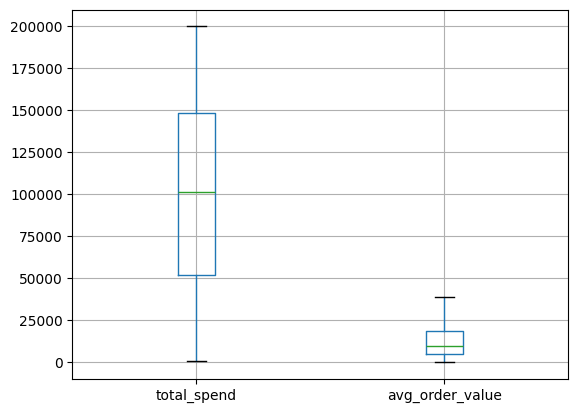

In [27]:
import matplotlib.pyplot as plt

df[['total_spend', 'avg_order_value']].boxplot()
plt.show()

Customer Lifetime

In [28]:
df['customer_lifetime_days'] = (df['last_purchase_date'] - df['first_purchase_date']).dt.days

Spend Per Day

In [29]:
df['spend_per_day'] = df['total_spend'] / (df['customer_lifetime_days'] + 1)

Order Frequency

In [30]:
df['order_frequency'] = df['total_orders'] / (df['customer_lifetime_days'] + 1)

Recency Groups

In [60]:
df['recency_days'] = (pd.Timestamp.today() - df['last_purchase_date']).dt.days

In [61]:
df['recency_days'].min(), df['recency_days'].max()

(682, 1159)

In [62]:
df['recency_group'] = pd.cut(
    df['recency_days'],
    bins=[-1, 30, 90, 180, 365, float('inf')],
    labels=['Active', 'Warm', 'Cold', 'Lost', 'Very Lost']
)

High Value Customer

In [33]:
df['high_value_customer'] = (df['total_spend'] > df['total_spend'].median()).astype(int)

Discount Behavior

In [34]:
df['used_discount'] = (df['discount_usage_%'] > 0).astype(int)

Average Order Value Category

In [35]:
df['aov_category'] = pd.qcut(df['avg_order_value'], q=3, labels=['Low','Medium','High'])

Customer Age

In [36]:
df['customer_age_days'] = (pd.Timestamp.today() - df['first_purchase_date']).dt.days

RFM Scoring

In [39]:
df['R_score'] = pd.qcut(df['recency_days'], 5, labels=[5,4,3,2,1])
df['F_score'] = pd.qcut(df['total_orders'], 5, labels=[1,2,3,4,5])
df['M_score'] = pd.qcut(df['total_spend'], 5, labels=[1,2,3,4,5])

df['RFM_score'] = df['R_score'].astype(str) + df['F_score'].astype(str) + df['M_score'].astype(str)

In [48]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             5000 non-null   object        
 1   first_purchase_date     5000 non-null   datetime64[ns]
 2   last_purchase_date      5000 non-null   datetime64[ns]
 3   total_orders            5000 non-null   int64         
 4   total_spend             5000 non-null   int64         
 5   avg_order_value         5000 non-null   float64       
 6   discount_usage_%        5000 non-null   float64       
 7   region                  5000 non-null   object        
 8   customer_segment        5000 non-null   object        
 9   preferred_payment       5000 non-null   object        
 10  recency_days            5000 non-null   int64         
 11  churn                   5000 non-null   object        
 12  customer_lifetime_days  5000 non-null   int64   

,0
customer_id,0
first_purchase_date,0
last_purchase_date,0
total_orders,0
total_spend,0
avg_order_value,0
discount_usage_%,0
region,0
customer_segment,0
preferred_payment,0


In [41]:
df.head()

,customer_id,first_purchase_date,last_purchase_date,total_orders,total_spend,avg_order_value,discount_usage_%,region,customer_segment,preferred_payment,...,order_frequency,recency_group,high_value_customer,used_discount,aov_category,customer_age_days,R_score,F_score,M_score,RFM_score
0,CUST1000,2023-03-18,2023-06-25,4,149858,37464.50,0.0,East,Mid Value,Debit Card,...,0.040000,Lost,1,0,High,1102,2,1,4,214
1,CUST1001,2023-02-04,2023-02-18,7,157299,22471.29,10.0,East,Mid Value,Credit Card,...,0.466667,Lost,1,1,High,1144,1,2,4,124
2,CUST1002,2023-04-25,2023-08-13,16,123523,7720.19,25.0,West,Mid Value,Credit Card,...,0.144144,Cold,1,1,Medium,1064,3,4,4,344
3,CUST1003,2023-05-19,2023-07-03,18,10028,557.11,15.0,East,Low Value,Debit Card,...,0.391304,Lost,0,1,Low,1040,2,5,1,251
4,CUST1004,2023-05-26,2023-11-21,19,107326,5648.74,10.0,East,High Value,Net Banking,...,0.105556,Warm,1,1,Low,1033,4,5,3,453


In [63]:
df.to_csv("cleaned_customer_data.csv", index=False)

In [64]:
from google.colab import files
files.download("cleaned_customer_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>